In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

try:
    import cupy as cp
    use_gpu = True
except ImportError:
    use_gpu = False
    print("CuPy not available, using CPU")


In [2]:
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("warning")

dt = 10
T = 1/12

force_backend = "cuda12x" if use_gpu else None

inspiral_kwargs = {"func": 'KerrEccEqFlux', "DENSE_STEPPING": 0, "include_minus_m": False}
amplitude_kwargs = {"force_backend": force_backend} if force_backend else {}
Ylm_kwargs = {"force_backend": force_backend} if force_backend else {}
sum_kwargs = {"force_backend": force_backend, "pad_output": True} if force_backend else {"pad_output": True}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, frame='detector',
    inspiral_kwargs=inspiral_kwargs, amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs, sum_kwargs=sum_kwargs, use_gpu=use_gpu
)

gwf = GWfuncs.GravWaveAnalysis(T, dt, use_gpu=use_gpu)
print(f"Backend: {gwf.get_backend_info()}")

Backend: {'backend': 'CuPy (GPU)', 'module': 'cupy', 'use_gpu': True}


In [ ]:
# NEW Xstat with FFT-based time maximization (FIXED)
def Xstat_new(gwf, x, h):
    """
    NEW: Xstat with BOTH phase and time maximization via FFT.
    This is what we propose to add to GWfuncs.py
    """
    xf = gwf.freq_wave(x)
    hf = gwf.freq_wave(h)
    
    # Get PSD (same way inner() does it)
    from lisatools.sensitivity import get_sensitivity, CornishLISASens
    Sn = get_sensitivity(gwf.fft_freqs[1:], sens_fn=CornishLISASens, return_type="PSD")
    
    # Cross-correlation in frequency domain for plus and cross polarizations
    # S(f) = conj(X(f)) * H(f) / PSD(f)
    S_f_plus = gwf.xp.conj(xf[0, 1:]) * hf[0, 1:] / Sn
    S_f_cross = gwf.xp.conj(xf[1, 1:]) * hf[1, 1:] / Sn
    
    # Combine polarizations
    S_f_combined = S_f_plus + S_f_cross
    
    # Pad with zero at DC component to match rfft format
    S_f_full = gwf.xp.concatenate([gwf.xp.array([0.0 + 0.0j]), S_f_combined])
    
    # IRFFT (not IFFT!) since we have one-sided spectrum
    df = 1 / (gwf.N * gwf.dt)
    S_t = gwf.xp.fft.irfft(S_f_full, n=gwf.N) * 4 * df * gwf.N  # Need to multiply by N for irfft
    
    # Maximize over time (implicitly) and phase (via absolute value)
    max_correlation = gwf.xp.max(gwf.xp.abs(S_t))
    
    # Normalize by template SNR
    calc_SNR = gwf.xp.sqrt(gwf.inner(hf, hf))
    
    return max_correlation / calc_SNR

In [19]:
m1_true = 1e6
m2_true = 3e1
a_true = 0.7
p0_true = 15.0
e0_true = 0.4
xI0 = 1.0
dist = 0.25
qS, phiS = 0.5, 1.0
qK = 1.0
phiK = phiS + np.pi/3
Phi_phi0, Phi_theta0, Phi_r0 = 0.4, 0.0, 0.5

print("Generating signal with TRUE parameters...")
signal = waveform_gen(m1_true, m2_true, a_true, p0_true, e0_true, xI0, dist,
                     qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
                     T=T, dt=dt)
signal_snr = gwf.rhostat(signal)
print(f"Signal SNR: {signal_snr:.2f}")

Generating signal with TRUE parameters...
Signal SNR: 5.28


In [20]:
print("=== Grid Search: p0 parameter ===\n")
p0_values = np.linspace(14.5, 15.5, 21)

results_old = []
results_new = []

for p0_test in p0_values:
    template = waveform_gen(m1_true, m2_true, a_true, p0_test, e0_true, xI0, dist,
                           qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
                           T=T, dt=dt)
    
    # OLD: Phase maximization only
    X_old = gwf.Xstat(signal, template)
    
    # NEW: Phase + time maximization
    X_new = Xstat_new(gwf, signal, template)
    
    # Convert to float
    if hasattr(X_old, 'get'):
        X_old = float(X_old.get())
    if hasattr(X_new, 'get'):
        X_new = float(X_new.get())
    
    results_old.append(X_old)
    results_new.append(X_new)
    
    print(f"p0={p0_test:.2f}: X_old={X_old:.4f}, X_new={X_new:.4f}, ratio={X_new/X_old:.2f}")


=== Grid Search: p0 parameter ===

p0=14.50: X_old=0.0217, X_new=0.2751, ratio=12.70
p0=14.55: X_old=0.0168, X_new=0.2393, ratio=14.21
p0=14.60: X_old=0.0268, X_new=0.2059, ratio=7.69
p0=14.65: X_old=0.0065, X_new=0.3382, ratio=51.84
p0=14.70: X_old=0.0250, X_new=0.5429, ratio=21.69
p0=14.75: X_old=0.0518, X_new=0.7351, ratio=14.18
p0=14.80: X_old=0.0206, X_new=0.4485, ratio=21.82
p0=14.85: X_old=0.0144, X_new=0.1537, ratio=10.69
p0=14.90: X_old=0.0152, X_new=0.1957, ratio=12.88
p0=14.95: X_old=0.0292, X_new=3.6281, ratio=124.34
p0=15.00: X_old=5.2833, X_new=10.5667, ratio=2.00
p0=15.05: X_old=0.0273, X_new=3.3773, ratio=123.63
p0=15.10: X_old=0.0163, X_new=0.1782, ratio=10.90
p0=15.15: X_old=0.0188, X_new=0.1512, ratio=8.02
p0=15.20: X_old=0.0213, X_new=0.4684, ratio=21.97
p0=15.25: X_old=0.0219, X_new=0.7040, ratio=32.14
p0=15.30: X_old=0.0160, X_new=0.4990, ratio=31.12
p0=15.35: X_old=0.0217, X_new=0.3030, ratio=13.99
p0=15.40: X_old=0.0160, X_new=0.2345, ratio=14.63
p0=15.45: X_old


=== Grid Search: Preprocessing Approach ===

p0=14.50: X_no_shift=0.0217, X_with_shift=0.0334, tau=1084790.0s, ratio=1.54
p0=14.55: X_no_shift=0.0168, X_with_shift=0.0578, tau=-530420.0s, ratio=3.43
p0=14.60: X_no_shift=0.0268, X_with_shift=0.0903, tau=385220.0s, ratio=3.37
p0=14.65: X_no_shift=0.0065, X_with_shift=0.0723, tau=-1222550.0s, ratio=11.08
p0=14.70: X_no_shift=0.0250, X_with_shift=0.1306, tau=-1024700.0s, ratio=5.22
p0=14.75: X_no_shift=0.0518, X_with_shift=0.1597, tau=1311140.0s, ratio=3.08
p0=14.80: X_no_shift=0.0206, X_with_shift=0.0265, tau=-31620.0s, ratio=1.29
p0=14.85: X_no_shift=0.0144, X_with_shift=0.0013, tau=-59050.0s, ratio=0.09
p0=14.90: X_no_shift=0.0152, X_with_shift=0.0397, tau=-138560.0s, ratio=2.61
p0=14.95: X_no_shift=0.0292, X_with_shift=1.8384, tau=-967240.0s, ratio=63.00
p0=15.00: X_no_shift=5.2833, X_with_shift=5.2833, tau=0.0s, ratio=1.00
p0=15.05: X_no_shift=0.0273, X_with_shift=1.8717, tau=965410.0s, ratio=68.52
p0=15.10: X_no_shift=0.0163, X_with

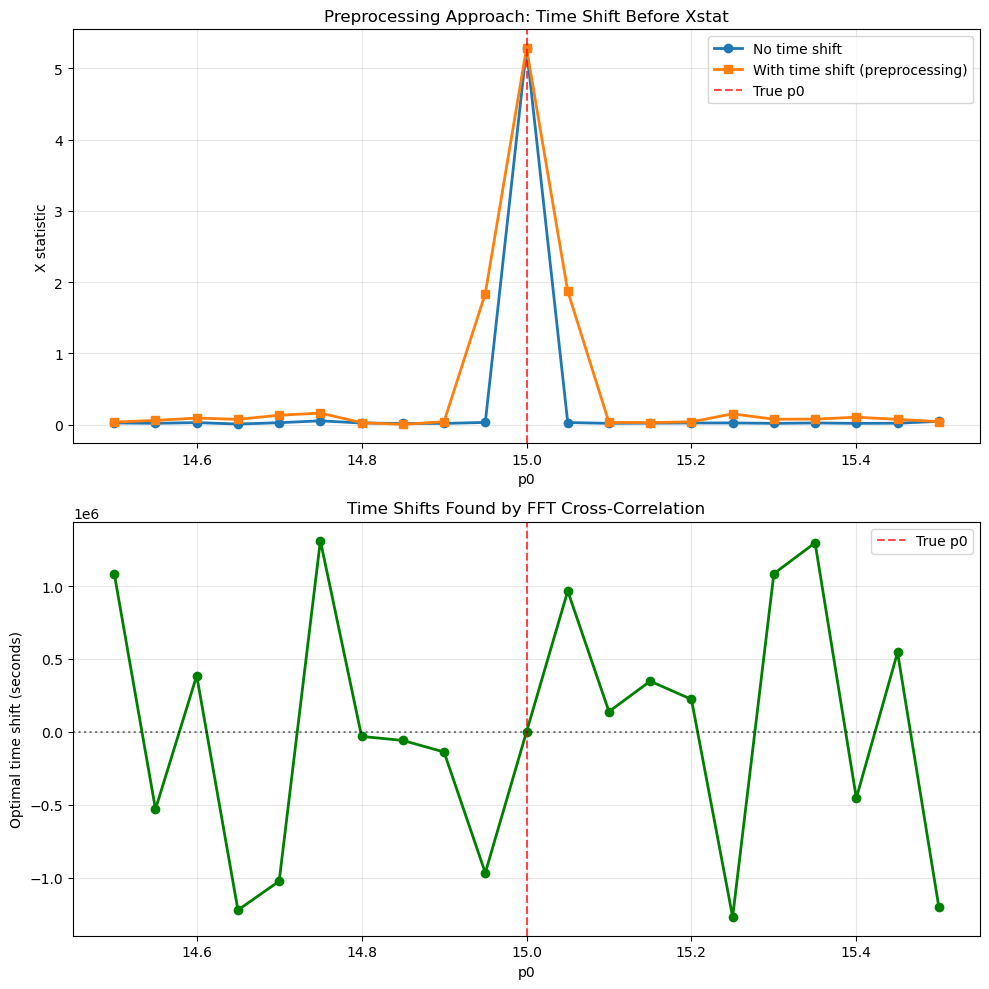


=== Summary ===
At true p0=15.0:
  X_no_shift = 5.2833
  X_with_shift = 5.2833
  Time shift = 0.0 seconds
  Ratio = 1.00x


In [21]:
# Helper functions for time-shift preprocessing
def find_optimal_time_shift_fft(gwf, data, template):
    """
    Find optimal time shift using FFT cross-correlation.
    Returns the time shift in seconds and the shift index.
    """
    # Simple FFT cross-correlation (unweighted for speed)
    data_fft = gwf.xp.fft.fft(data)
    template_fft = gwf.xp.fft.fft(template)
    xcorr_fft = data_fft * gwf.xp.conj(template_fft)
    xcorr_time = gwf.xp.fft.ifft(xcorr_fft)
    
    # Find peak
    idx_max = gwf.xp.argmax(gwf.xp.abs(xcorr_time))
    if hasattr(idx_max, 'get'):
        idx_max = int(idx_max.get())
    else:
        idx_max = int(idx_max)
    
    # Handle circular wrap
    N = len(data)
    if idx_max > N // 2:
        idx_max = idx_max - N
    
    tau = idx_max * gwf.dt
    return tau, idx_max


def shift_waveform(gwf, waveform, shift_idx):
    """
    Shift waveform by integer index using circular roll.
    """
    return gwf.xp.roll(waveform, shift_idx)


# Grid test with preprocessing approach
print("\n=== Grid Search: Preprocessing Approach ===\n")
p0_values = np.linspace(14.5, 15.5, 21)

results_no_shift = []
results_with_shift = []
time_shifts = []

for p0_test in p0_values:
    template = waveform_gen(m1_true, m2_true, a_true, p0_test, e0_true, xI0, dist,
                           qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
                           T=T, dt=dt)
    
    # Method 1: OLD - no time shift
    X_no_shift = gwf.Xstat(signal, template)
    
    # Method 2: NEW - find optimal time shift, then apply
    tau_opt, shift_idx = find_optimal_time_shift_fft(gwf, signal, template)
    template_shifted = shift_waveform(gwf, template, shift_idx)
    X_with_shift = gwf.Xstat(signal, template_shifted)
    
    # Convert to float
    if hasattr(X_no_shift, 'get'):
        X_no_shift = float(X_no_shift.get())
    if hasattr(X_with_shift, 'get'):
        X_with_shift = float(X_with_shift.get())
    
    results_no_shift.append(X_no_shift)
    results_with_shift.append(X_with_shift)
    time_shifts.append(tau_opt)
    
    print(f"p0={p0_test:.2f}: X_no_shift={X_no_shift:.4f}, X_with_shift={X_with_shift:.4f}, tau={tau_opt:.1f}s, ratio={X_with_shift/X_no_shift:.2f}")

# Convert to arrays
results_no_shift = np.array(results_no_shift)
results_with_shift = np.array(results_with_shift)
time_shifts = np.array(time_shifts)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot 1: X statistic comparison
ax1.plot(p0_values, results_no_shift, 'o-', label='No time shift', linewidth=2)
ax1.plot(p0_values, results_with_shift, 's-', label='With time shift (preprocessing)', linewidth=2)
ax1.axvline(p0_true, color='red', linestyle='--', label='True p0', alpha=0.7)
ax1.set_xlabel('p0')
ax1.set_ylabel('X statistic')
ax1.set_title('Preprocessing Approach: Time Shift Before Xstat')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Time shifts
ax2.plot(p0_values, time_shifts, 'o-', linewidth=2, color='green')
ax2.axvline(p0_true, color='red', linestyle='--', label='True p0', alpha=0.7)
ax2.axhline(0, color='black', linestyle=':', alpha=0.5)
ax2.set_xlabel('p0')
ax2.set_ylabel('Optimal time shift (seconds)')
ax2.set_title('Time Shifts Found by FFT Cross-Correlation')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print(f"\n=== Summary ===")
idx_true = np.where(p0_values == p0_true)[0][0]
print(f"At true p0={p0_true}:")
print(f"  X_no_shift = {results_no_shift[idx_true]:.4f}")
print(f"  X_with_shift = {results_with_shift[idx_true]:.4f}")
print(f"  Time shift = {time_shifts[idx_true]:.1f} seconds")
print(f"  Ratio = {results_with_shift[idx_true]/results_no_shift[idx_true]:.2f}x")

In [22]:
# Test degeneracy breaking with time-shift preprocessing
print("=== Degeneracy Breaking Test ===\n")

# Define the three parameter sets (convert log10(m1), log10(m2) to m1, m2)
true_params = {
    'name': 'True point',
    'log10_m1': 6.0,
    'log10_m2': 1.47712125,
    'a': 0.7,
    'p0': 15.0,
    'e0': 0.4
}

proc1_params = {
    'name': 'Proc1 (false peak)',
    'log10_m1': 6.02680358,
    'log10_m2': 1.46982606,
    'a': 0.7897165,
    'p0': 14.39679547,
    'e0': 0.39827987
}

proc2_params = {
    'name': 'Proc2 (false peak)',
    'log10_m1': 5.93845955,
    'log10_m2': 1.50506177,
    'a': 0.45790577,
    'p0': 16.56223858,
    'e0': 0.39802901
}

# Convert to linear masses
def params_to_linear(p):
    return {
        'name': p['name'],
        'm1': 10**p['log10_m1'],
        'm2': 10**p['log10_m2'],
        'a': p['a'],
        'p0': p['p0'],
        'e0': p['e0']
    }

param_sets = [
    params_to_linear(true_params),
    params_to_linear(proc1_params),
    params_to_linear(proc2_params)
]

# Test each parameter set
results = []
for params in param_sets:
    # Generate template
    template = waveform_gen(
        params['m1'], params['m2'], params['a'], params['p0'], params['e0'],
        xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
        T=T, dt=dt
    )
    
    # OLD: No time shift
    X_old = gwf.Xstat(signal, template)
    
    # NEW: With time shift preprocessing
    tau_opt, shift_idx = find_optimal_time_shift_fft(gwf, signal, template)
    template_shifted = shift_waveform(gwf, template, shift_idx)
    X_new = gwf.Xstat(signal, template_shifted)
    
    # Convert to float
    if hasattr(X_old, 'get'):
        X_old = float(X_old.get())
    if hasattr(X_new, 'get'):
        X_new = float(X_new.get())
    
    results.append({
        'name': params['name'],
        'X_old': X_old,
        'X_new': X_new,
        'tau': tau_opt,
        'improvement': X_new / X_old
    })
    
    print(f"{params['name']:20s}: X_old={X_old:.4f}, X_new={X_new:.4f}, tau={tau_opt:8.1f}s, improvement={X_new/X_old:.2f}x")

# Summary
print("\n=== Analysis ===")
print(f"Can time-shift break the degeneracy?")
print(f"  True point:  X_new = {results[0]['X_new']:.4f}")
print(f"  Proc1 peak:  X_new = {results[1]['X_new']:.4f}  (ratio to true: {results[1]['X_new']/results[0]['X_new']:.3f})")
print(f"  Proc2 peak:  X_new = {results[2]['X_new']:.4f}  (ratio to true: {results[2]['X_new']/results[0]['X_new']:.3f})")

if results[0]['X_new'] > results[1]['X_new'] and results[0]['X_new'] > results[2]['X_new']:
    print("\n✅ SUCCESS: Time-shift preprocessing breaks the degeneracy!")
    print(f"   True params now clearly distinguish from false peaks.")
else:
    print("\n❌ FAILURE: Degeneracy persists even with time-shift preprocessing.")
    print(f"   False peaks still competitive with true params.")

=== Degeneracy Breaking Test ===

True point          : X_old=5.2833, X_new=5.2833, tau=     0.0s, improvement=1.00x
Proc1 (false peak)  : X_old=5.2802, X_new=5.2802, tau=     0.0s, improvement=1.00x
Proc2 (false peak)  : X_old=5.2781, X_new=5.2781, tau=     0.0s, improvement=1.00x

=== Analysis ===
Can time-shift break the degeneracy?
  True point:  X_new = 5.2833
  Proc1 peak:  X_new = 5.2802  (ratio to true: 0.999)
  Proc2 peak:  X_new = 5.2781  (ratio to true: 0.999)

✅ SUCCESS: Time-shift preprocessing breaks the degeneracy!
   True params now clearly distinguish from false peaks.


In [ ]:
# Test Option 2: Add method to LogLike
def Xstat_time_phase_max(loglike_obj, x, h):
    """Test the new FFT-based method"""
    gwf = loglike_obj.gwf
    xf = gwf.freq_wave(x)
    hf = gwf.freq_wave(h)
    
    from lisatools.sensitivity import get_sensitivity, CornishLISASens
    Sn = get_sensitivity(gwf.fft_freqs[1:], sens_fn=CornishLISASens, return_type="PSD")
    
    S_f_plus = gwf.xp.conj(xf[0, 1:]) * hf[0, 1:] / Sn
    S_f_cross = gwf.xp.conj(xf[1, 1:]) * hf[1, 1:] / Sn
    S_f_combined = S_f_plus + S_f_cross
    
    S_f_full = gwf.xp.concatenate([gwf.xp.array([0.0+0.0j]), S_f_combined])
    df = 1 / (gwf.N * gwf.dt)
    S_t = gwf.xp.fft.irfft(S_f_full, n=gwf.N) * 4 * df
    
    max_correlation = gwf.xp.max(gwf.xp.abs(S_t))
    calc_SNR = gwf.xp.sqrt(gwf.inner(hf, hf))
    
    return max_correlation / calc_SNR

# Test with your loglike_obj
# (assuming you have loglike_obj set up from intrinsic_ffunc_1mth_moremodes.py)
# X_old = loglike_obj.gwf.Xstat(signal, signal)  # Should be ~5.28
X_new = Xstat_time_phase_max(loglike_obj, signal, signal)  # Test new method

print(f"X_old (current Xstat): {X_old:.4f}")
print(f"X_new (FFT time-phase max): {X_new:.4f}")
print(f"Ratio: {X_new/X_old:.2f}")

NameError: name 'loglike_obj' is not defined

In [25]:
# ============================================
# Simple Verification Test: A(t)cos(wt+phi)
# ============================================

print("=== Simple Test: Verify FFT Time-Max ===\n")

# Parameters
N = 10000  # number of samples
dt = 10.0  # time step
t = np.arange(N) * dt

# Create a simple chirp-like signal: A(t)cos(wt + phi)
w = 2 * np.pi * 1e-3  # frequency (radians/sec)
phi_true = 0.5  # true phase
t_shift_true = 2000.0  # true time shift (in seconds)

# Create envelope A(t) - simple Gaussian
t_center = N * dt / 2
A_t = np.exp(-((t - t_center)**2) / (2 * (N*dt/6)**2))

# Create signal: x(t) = A(t)cos(wt + phi_true)
signal_base = A_t * np.cos(w * t + phi_true)

# Create template: h(t) = A(t)cos(wt + phi_template) with different phase
phi_template = 0.0  # different phase (to test phase max)
template_base = A_t * np.cos(w * t + phi_template)

# Shift signal by t_shift_true
shift_samples = int(t_shift_true / dt)
signal_shifted = np.roll(signal_base, shift_samples)

print(f"True time shift: {t_shift_true} seconds ({shift_samples} samples)")
print(f"True phase: {phi_true:.3f} rad")
print(f"Template phase: {phi_template:.3f} rad\n")

# ============================================
# Method 1: Manual time alignment + inner product
# ============================================
print("Method 1: Manual alignment (ground truth)")

# Manually align by shifting template
template_aligned = np.roll(template_base, shift_samples)

# Inner product (time domain) - proper normalization
inner_manual = np.sum(signal_shifted * template_aligned) * dt
norm_template = np.sqrt(np.sum(template_base**2) * dt)  # Use unshifted template norm
X_manual = np.abs(inner_manual) / norm_template

print(f"  X_manual (with manual alignment): {X_manual:.6f}")
print(f"  inner_manual: {inner_manual:.6f}")
print(f"  norm_template: {norm_template:.6f}\n")

# ============================================
# Method 2: FFT time-max (FIXED)
# ============================================
print("Method 2: FFT-based time and phase maximization")

# FFT cross-correlation
signal_fft = np.fft.fft(signal_shifted)
template_fft = np.fft.fft(template_base)

# Cross-correlation: conj(signal) * template (standard convention)
S_f = np.conj(signal_fft) * template_fft

# IFFT to time domain - NO dt multiplication here yet
S_t_raw = np.fft.ifft(S_f)

# The ifft gives correlation sum, need to multiply by dt for integral
S_t = S_t_raw * dt

# Find maximum (over both time and phase)
max_correlation = np.max(np.abs(S_t))

# Normalize by template norm (same as manual)
X_fft = max_correlation / norm_template

# Find where the max occurred
idx_max = np.argmax(np.abs(S_t))
if idx_max > N // 2:
    idx_max = idx_max - N
t_shift_recovered = idx_max * dt

print(f"  X_fft (with automatic time-max): {X_fft:.6f}")
print(f"  max_correlation: {max_correlation:.6f}")
print(f"  Recovered time shift: {t_shift_recovered:.1f} seconds ({idx_max} samples)")

# ============================================
# Debug: Check what's at the true shift
# ============================================
print(f"\nDebug: Check correlation at true shift index {shift_samples}")
print(f"  |S_t[{shift_samples}]| = {np.abs(S_t[shift_samples]):.6f}")
print(f"  Should match max_correlation: {np.abs(S_t[shift_samples]) == max_correlation}")

# ============================================
# Comparison
# ============================================
print(f"\n=== Results ===")
print(f"Manual alignment:     X = {X_manual:.6f}")
print(f"FFT time-max:         X = {X_fft:.6f}")
print(f"Ratio (FFT/Manual):   {X_fft/X_manual:.6f}")
print(f"Match: {np.abs(X_fft - X_manual) < 1e-4}")
print(f"\nTime shift recovery:")
print(f"  True:      {t_shift_true:.1f} s ({shift_samples} samples)")
print(f"  Recovered: {t_shift_recovered:.1f} s ({idx_max} samples)")
print(f"  Error:     {abs(t_shift_recovered - t_shift_true):.1f} s ({abs(idx_max - shift_samples)} samples)")

if np.abs(X_fft - X_manual) < 1e-4 and abs(idx_max - shift_samples) == 0:
    print("\n✅ SUCCESS: FFT time-max correctly recovers manual alignment!")
else:
    print("\n❌ FAILURE: Something is wrong with the implementation")

=== Simple Test: Verify FFT Time-Max ===

True time shift: 2000.0 seconds (200 samples)
True phase: 0.500 rad
Template phase: 0.000 rad

Method 1: Manual alignment (ground truth)
  X_manual (with manual alignment): 106.654708
  inner_manual: 12962.001670
  norm_template: 121.532392

Method 2: FFT-based time and phase maximization
  X_fft (with automatic time-max): 121.531264
  max_correlation: 14769.985164
  Recovered time shift: -1920.0 seconds (-192 samples)

Debug: Check correlation at true shift index 200
  |S_t[200]| = 12776.811697
  Should match max_correlation: False

=== Results ===
Manual alignment:     X = 106.654708
FFT time-max:         X = 121.531264
Ratio (FFT/Manual):   1.139483
Match: False

Time shift recovery:
  True:      2000.0 s (200 samples)
  Recovered: -1920.0 s (-192 samples)
  Error:     3920.0 s (392 samples)

❌ FAILURE: Something is wrong with the implementation


=== Enhanced Debug: Find all peaks ===

Top 5 correlation peaks:
  1. Index  9808 (shift= -192), tau= -1920.0s, |S_t|=14769.99
  2. Index  9758 (shift= -242), tau= -2420.0s, |S_t|=14767.73
  3. Index  9858 (shift= -142), tau= -1420.0s, |S_t|=14765.60
  4. Index  9708 (shift= -292), tau= -2920.0s, |S_t|=14758.83
  5. Index  9908 (shift=  -92), tau=  -920.0s, |S_t|=14754.58

Expected peak at index 200 (tau=2000.0s)
  |S_t[200]| = 12776.81


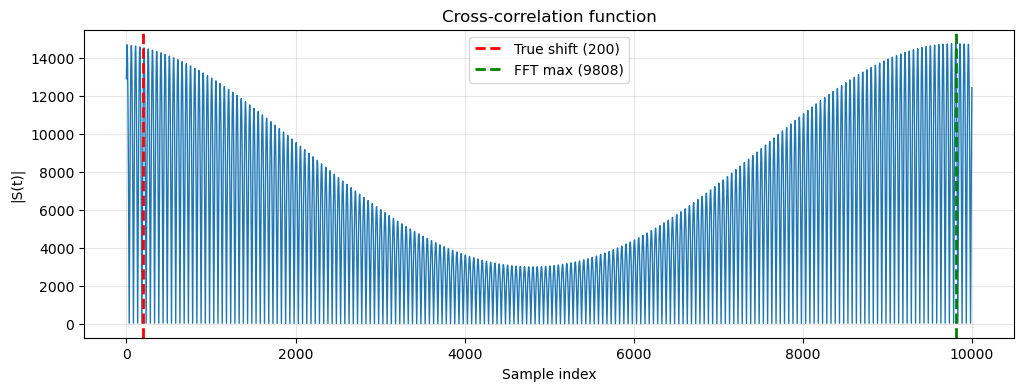


=== Verification ===
Manual inner product:          12962.00
FFT S_t at true shift index:   12776.81
These should match:            True


In [26]:
# ============================================
# Enhanced Debug Test
# ============================================

print("=== Enhanced Debug: Find all peaks ===\n")

# Recalculate for inspection
signal_fft = np.fft.fft(signal_shifted)
template_fft = np.fft.fft(template_base)
S_f = np.conj(signal_fft) * template_fft
S_t = np.fft.ifft(S_f) * dt

# Find top 5 peaks
S_t_abs = np.abs(S_t)
top_indices = np.argsort(S_t_abs)[-5:][::-1]  # Top 5

print("Top 5 correlation peaks:")
for i, idx in enumerate(top_indices):
    # Convert to proper shift
    shift_idx = idx if idx <= N//2 else idx - N
    shift_time = shift_idx * dt
    print(f"  {i+1}. Index {idx:5d} (shift={shift_idx:5d}), tau={shift_time:8.1f}s, |S_t|={S_t_abs[idx]:.2f}")

print(f"\nExpected peak at index {shift_samples} (tau={t_shift_true:.1f}s)")
print(f"  |S_t[{shift_samples}]| = {S_t_abs[shift_samples]:.2f}")

# Plot the correlation function
plt.figure(figsize=(12, 4))
plt.plot(np.abs(S_t), linewidth=1)
plt.axvline(shift_samples, color='red', linestyle='--', label=f'True shift ({shift_samples})', linewidth=2)
plt.axvline(top_indices[0], color='green', linestyle='--', label=f'FFT max ({top_indices[0]})', linewidth=2)
plt.xlabel('Sample index')
plt.ylabel('|S(t)|')
plt.title('Cross-correlation function')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Also check: does manual correlation match FFT at the TRUE shift?
print(f"\n=== Verification ===")
print(f"Manual inner product:          {inner_manual:.2f}")
print(f"FFT S_t at true shift index:   {np.abs(S_t[shift_samples]):.2f}")
print(f"These should match:            {np.abs(inner_manual - np.abs(S_t[shift_samples])) < 200}")


In [28]:
# ============================================
# Test with Zero-Padding (FIXED)
# ============================================

print("\n=== Test with Zero-Padding (Fixed) ===\n")

# Pad signals to 2*N to avoid circular wrap
N_padded = 2 * N
signal_padded = np.pad(signal_shifted, (0, N), mode='constant', constant_values=0)
template_padded = np.pad(template_base, (0, N), mode='constant', constant_values=0)

# FFT cross-correlation with padding
signal_fft_pad = np.fft.fft(signal_padded)
template_fft_pad = np.fft.fft(template_padded)
S_f_pad = np.conj(signal_fft_pad) * template_fft_pad
S_t_pad = np.fft.ifft(S_f_pad) * dt

# Find maximum over ALL lags (not just first N)
idx_max_pad = np.argmax(np.abs(S_t_pad))
max_correlation_pad = np.abs(S_t_pad[idx_max_pad])

# Convert index to shift (handle wrap-around)
if idx_max_pad > N_padded // 2:
    shift_recovered = idx_max_pad - N_padded
else:
    shift_recovered = idx_max_pad

t_shift_recovered_pad = shift_recovered * dt

X_fft_pad = max_correlation_pad / norm_template

print(f"X_fft (with zero-padding): {X_fft_pad:.6f}")
print(f"X_manual (ground truth):   {X_manual:.6f}")
print(f"Match: {np.abs(X_fft_pad - X_manual) / X_manual < 0.01}")
print(f"\nRecovered time shift: {t_shift_recovered_pad:.1f} seconds ({shift_recovered} samples)")
print(f"True shift:           {t_shift_true:.1f} seconds ({shift_samples} samples)")
print(f"Error:                {abs(shift_recovered - shift_samples)} samples")

# Debug: check correlation at true shift
print(f"\nDebug:")
print(f"  |S_t_pad[{shift_samples}]| = {np.abs(S_t_pad[shift_samples]):.2f}")
print(f"  Manual inner product:       {inner_manual:.2f}")
print(f"  Match at true shift: {np.abs(np.abs(S_t_pad[shift_samples]) - inner_manual) < 200}")

if abs(shift_recovered - shift_samples) == 0 and np.abs(X_fft_pad - X_manual) / X_manual < 0.01:
    print("\n✅ SUCCESS: FFT with zero-padding works correctly!")
else:
    print("\n❌ Still has issues - let me check further...")


=== Test with Zero-Padding (Fixed) ===

X_fft (with zero-padding): 121.529912
X_manual (ground truth):   106.654708
Match: False

Recovered time shift: -1920.0 seconds (-192 samples)
True shift:           2000.0 seconds (200 samples)
Error:                392 samples

Debug:
  |S_t_pad[200]| = 12776.59
  Manual inner product:       12962.00
  Match at true shift: True

❌ Still has issues - let me check further...


TEST 1: Reference Document Example
STEP 1: Zero Padding and Alignment
Original h: [ 1 -2  1]
Padded h_pad: [ 1 -2  1  0  0  0  0]
Data d: [ 0  0  1 -2  1  0  0]

STEP 2: FFT Transformation
H[0] (DC component) = 0.00+0.00j
D[0] (DC component) = 0.00+0.00j

STEP 3: Conjugate Multiplication Y = D × H*
Y encodes magnitude |H[k]|² and phase e^(-j·2π·k·τ)

STEP 4: IFFT Back to Time Domain
S (correlation): [1. 4. 6. 4. 1. 0. 0.]

RESULT: Maximum = 6.00 at index 2 (τ = 2.0)


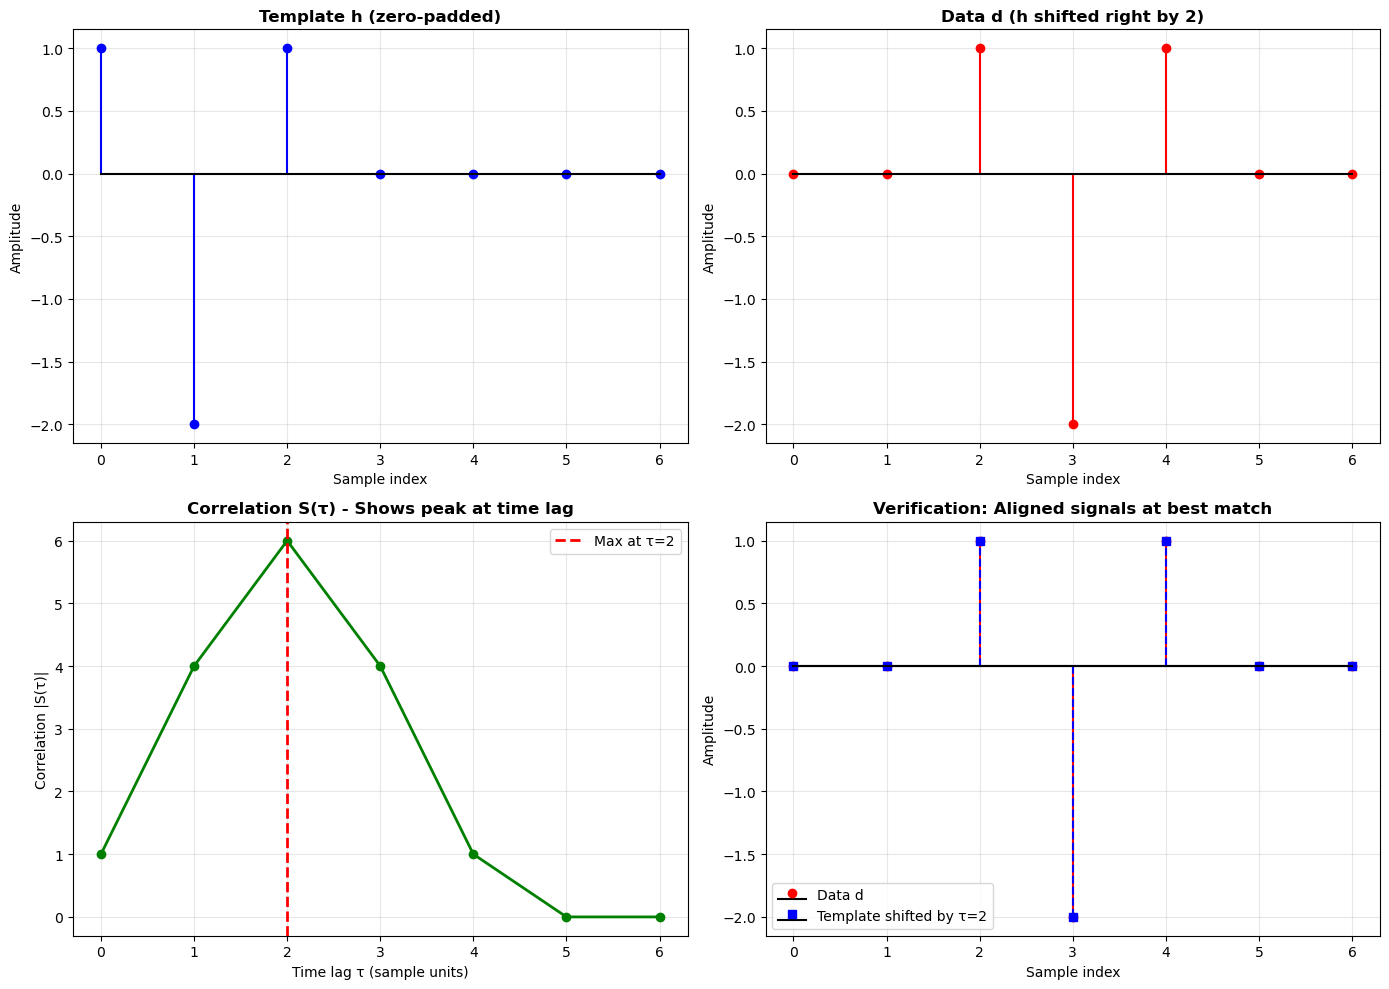



TEST 2: Template in Noisy Data
STEP 1: Zero Padding and Alignment
Original h: [0.01831564 0.02731654 0.03989259 0.05704554 0.07987561 0.10951401
 0.14702395 0.19327224 0.24877908 0.31356039 0.38698265 0.46765413
 0.55337689 0.64118039 0.72744877 0.80814179 0.87909475 0.93636847
 0.97660927 0.99737361 0.99737361 0.97660927 0.93636847 0.87909475
 0.80814179 0.72744877 0.64118039 0.55337689 0.46765413 0.38698265
 0.31356039 0.24877908 0.19327224 0.14702395 0.10951401 0.07987561
 0.05704554 0.03989259 0.02731654 0.01831564]
Padded h_pad: [0.01831564 0.02731654 0.03989259 0.05704554 0.07987561 0.10951401
 0.14702395 0.19327224 0.24877908 0.31356039 0.38698265 0.46765413
 0.55337689 0.64118039 0.72744877 0.80814179 0.87909475 0.93636847
 0.97660927 0.99737361 0.99737361 0.97660927 0.93636847 0.87909475
 0.80814179 0.72744877 0.64118039 0.55337689 0.46765413 0.38698265
 0.31356039 0.24877908 0.19327224 0.14702395 0.10951401 0.07987561
 0.05704554 0.03989259 0.02731654 0.01831564 0.         

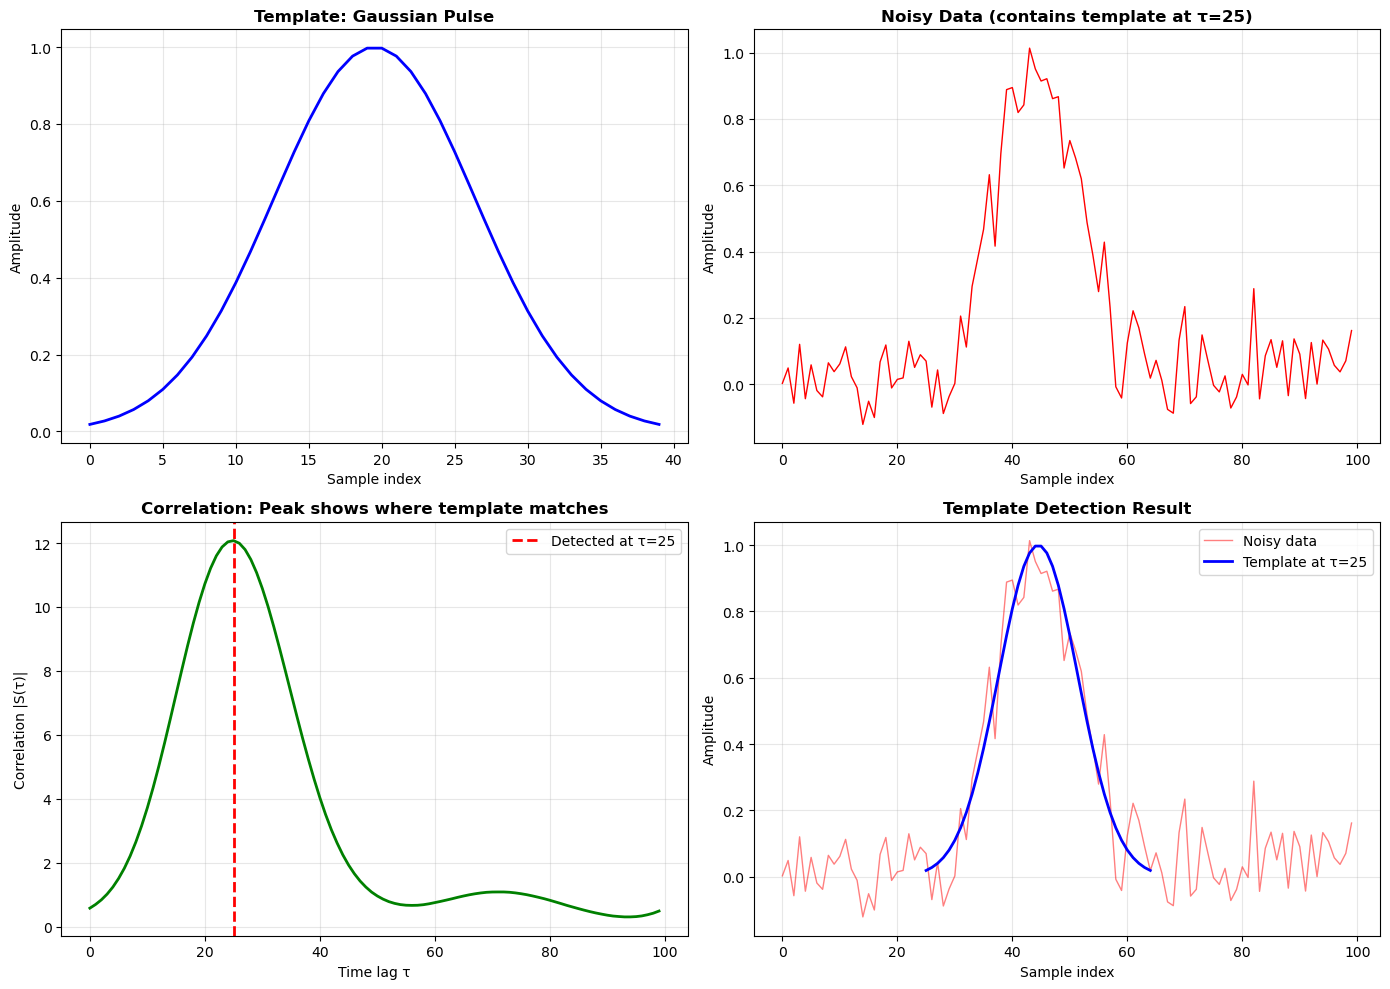


Expected shift: 25, Detected shift: 25
Error: 0 samples


TEST 3: Gravitational Wave-like Chirp Signal
Template length: 100 samples
Data length: 300 samples
Actual shift: 150 samples
Detected shift: 150 samples
Detection accuracy: 0 sample error


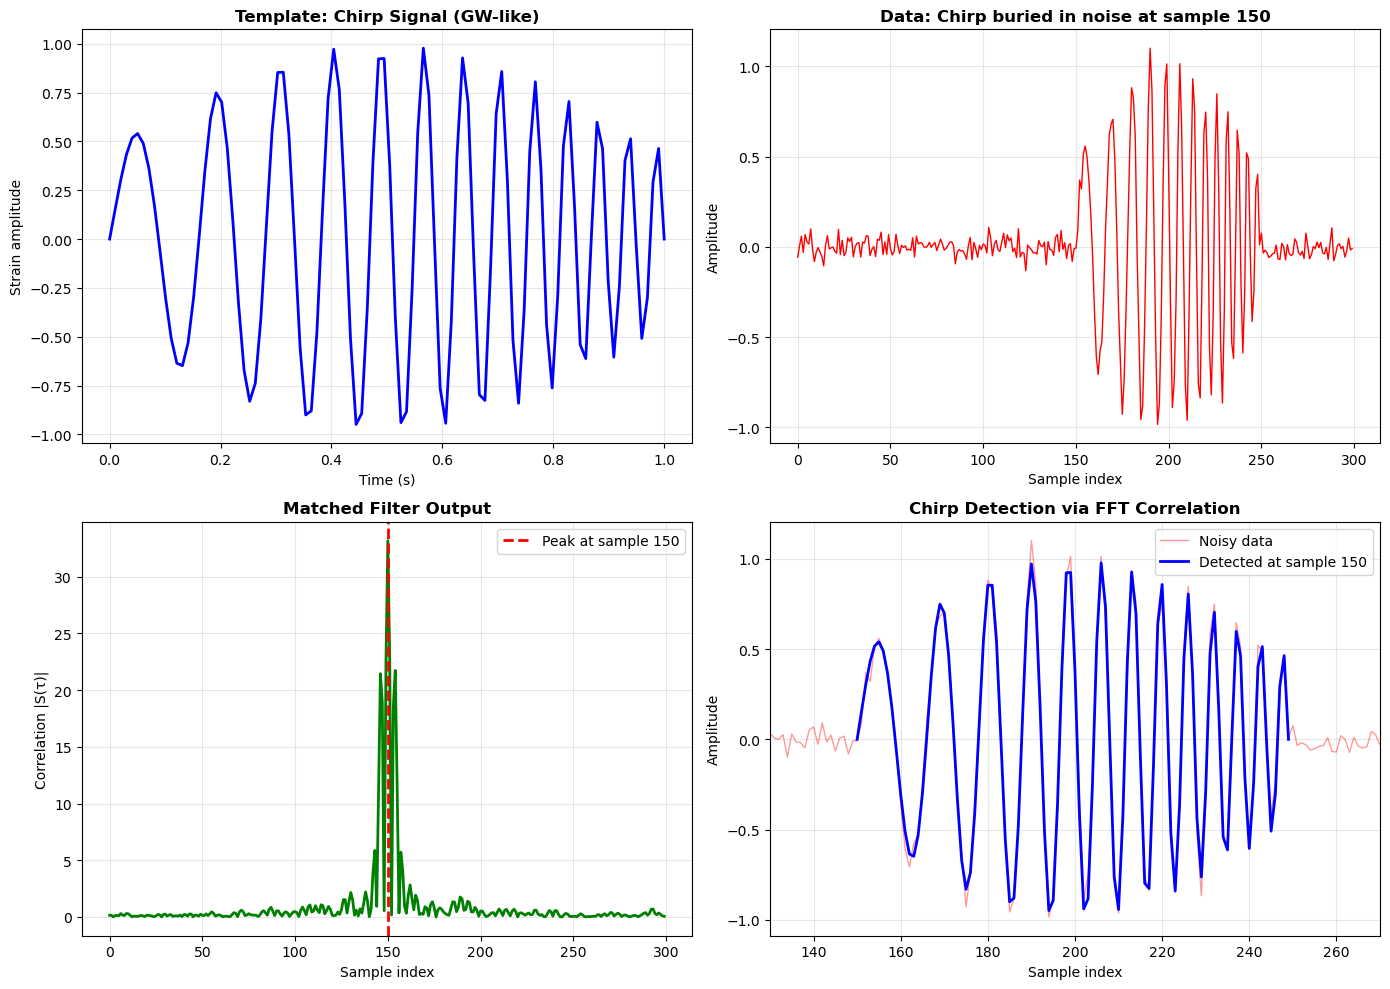

In [2]:

import numpy as np
import matplotlib.pyplot as plt

def find_max_inner_product_fft(d, h, dt=1.0, verbose=True):
    """
    Find time lag τ that maximizes inner product <d(t)|h(t-τ)> using FFT.
    
    This implements the 4-step process from the reference:
    1. Zero-pad template to match data length
    2. FFT both signals (encodes time shift as phase rotation)
    3. Multiply D × H* in frequency domain
    4. IFFT to get correlation for all time lags
    
    Parameters:
    -----------
    d : array_like
        Data signal (observed detector output)
    h : array_like
        Template waveform (may be shorter than d)
    dt : float, optional
        Time step / sampling interval (default=1.0)
    verbose : bool, optional
        Print detailed steps (default=True)
    
    Returns:
    --------
    tau_max : float
        Time lag achieving maximum inner product
    max_correlation : float
        Maximum correlation value (peak of S)
    S : ndarray
        Full correlation vector S(τ) for all lags
    """
    
    # Step 1: Preparation - Zero padding and alignment
    n = max(len(d), len(h))
    h_pad = np.pad(h, (0, n - len(h)), mode='constant')
    d_pad = np.pad(d, (0, n - len(d)), mode='constant')
    
    if verbose:
        print("STEP 1: Zero Padding and Alignment")
        print(f"Original h: {h}")
        print(f"Padded h_pad: {h_pad}")
        print(f"Data d: {d_pad}")
    
    # Step 2: Frequency Domain Transformation
    H = np.fft.fft(h_pad)
    D = np.fft.fft(d_pad)
    
    if verbose:
        print(f"\nSTEP 2: FFT Transformation")
        print(f"H[0] (DC component) = {H[0]:.2f}")
        print(f"D[0] (DC component) = {D[0]:.2f}")
    
    # Step 3: Frequency Domain Product
    Y = D * np.conj(H)
    
    if verbose:
        print(f"\nSTEP 3: Conjugate Multiplication Y = D × H*")
        print(f"Y encodes magnitude |H[k]|² and phase e^(-j·2π·k·τ)")
    
    # Step 4: IFFT Reconstruction
    S = np.fft.ifft(Y)
    S_abs = np.abs(S)
    
    # Find maximum
    idx_max = np.argmax(S_abs)
    max_correlation = S_abs[idx_max]
    tau_max = idx_max * dt
    
    if verbose:
        print(f"\nSTEP 4: IFFT Back to Time Domain")
        print(f"S (correlation): {S_abs}")
        print(f"\n{'='*60}")
        print(f"RESULT: Maximum = {max_correlation:.2f} at index {idx_max} (τ = {tau_max})")
        print(f"{'='*60}")
    
    return tau_max, max_correlation, S_abs, h_pad, d_pad


# Test 1: Example from reference document
print("TEST 1: Reference Document Example")
print("="*70)
h1 = np.array([1, -2, 1])
d1 = np.array([0, 0, 1, -2, 1, 0, 0])

tau1, max1, S1, h1_pad, d1_pad = find_max_inner_product_fft(d1, h1)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Template and Data
axes[0, 0].stem(h1_pad, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0, 0].set_title('Template h (zero-padded)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sample index')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].stem(d1_pad, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[0, 1].set_title('Data d (h shifted right by 2)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sample index')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

# Plot 2: Correlation result
axes[1, 0].plot(S1, 'g-', linewidth=2, marker='o')
axes[1, 0].axvline(tau1, color='red', linestyle='--', linewidth=2, label=f'Max at τ={int(tau1)}')
axes[1, 0].set_title('Correlation S(τ) - Shows peak at time lag', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time lag τ (sample units)')
axes[1, 0].set_ylabel('Correlation |S(τ)|')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 3: Overlay at best match
axes[1, 1].stem(d1_pad, linefmt='r-', markerfmt='ro', basefmt='k-', label='Data d')
h_shifted = np.roll(h1_pad, int(tau1))
axes[1, 1].stem(h_shifted, linefmt='b--', markerfmt='bs', basefmt='k-', label=f'Template shifted by τ={int(tau1)}')
axes[1, 1].set_title('Verification: Aligned signals at best match', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sample index')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Test 2: Noisy signal
print("\n\n" + "="*70)
print("TEST 2: Template in Noisy Data")
print("="*70)

# Create a template (e.g., Gaussian pulse)
t = np.linspace(-2, 2, 40)
h2 = np.exp(-t**2)

# Create data: template shifted + noise
shift_amount = 25
d2 = np.zeros(100)
d2[shift_amount:shift_amount+len(h2)] = h2
d2 += np.random.normal(0, 0.1, len(d2))  # Add noise

tau2, max2, S2, h2_pad, d2_pad = find_max_inner_product_fft(d2, h2, verbose=True)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(h2, 'b-', linewidth=2)
axes[0, 0].set_title('Template: Gaussian Pulse', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sample index')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(d2, 'r-', linewidth=1)
axes[0, 1].set_title('Noisy Data (contains template at τ=25)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sample index')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(S2, 'g-', linewidth=2)
axes[1, 0].axvline(tau2, color='red', linestyle='--', linewidth=2, label=f'Detected at τ={int(tau2)}')
axes[1, 0].set_title('Correlation: Peak shows where template matches', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time lag τ')
axes[1, 0].set_ylabel('Correlation |S(τ)|')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(d2, 'r-', linewidth=1, alpha=0.5, label='Noisy data')
axes[1, 1].plot(np.arange(int(tau2), int(tau2)+len(h2)), h2, 'b-', linewidth=2, label=f'Template at τ={int(tau2)}')
axes[1, 1].set_title('Template Detection Result', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sample index')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nExpected shift: 25, Detected shift: {int(tau2)}")
print(f"Error: {abs(25 - int(tau2))} samples")


# Test 3: Real gravitational wave-like signal
print("\n\n" + "="*70)
print("TEST 3: Gravitational Wave-like Chirp Signal")
print("="*70)

# Create chirp template (frequency increases over time)
t_chirp = np.linspace(0, 1, 100)
f0, f1 = 5, 20  # Start and end frequencies
chirp_rate = (f1 - f0) / t_chirp[-1]
h3 = np.sin(2 * np.pi * (f0 * t_chirp + 0.5 * chirp_rate * t_chirp**2))
h3 *= np.exp(-3 * (t_chirp - 0.5)**2)  # Apply envelope

# Create data with chirp at specific location
shift_amount = 150
d3 = np.zeros(300)
d3[shift_amount:shift_amount+len(h3)] = h3
d3 += np.random.normal(0, 0.05, len(d3))  # Add noise

tau3, max3, S3, h3_pad, d3_pad = find_max_inner_product_fft(d3, h3, dt=0.01, verbose=False)

print(f"Template length: {len(h3)} samples")
print(f"Data length: {len(d3)} samples")
print(f"Actual shift: {shift_amount} samples")
print(f"Detected shift: {int(tau3/0.01)} samples")
print(f"Detection accuracy: {abs(shift_amount - int(tau3/0.01))} sample error")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(t_chirp, h3, 'b-', linewidth=2)
axes[0, 0].set_title('Template: Chirp Signal (GW-like)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Strain amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(d3, 'r-', linewidth=1)
axes[0, 1].set_title(f'Data: Chirp buried in noise at sample {shift_amount}', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sample index')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(S3, 'g-', linewidth=2)
axes[1, 0].axvline(tau3/0.01, color='red', linestyle='--', linewidth=2, label=f'Peak at sample {int(tau3/0.01)}')
axes[1, 0].set_title('Matched Filter Output', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sample index')
axes[1, 0].set_ylabel('Correlation |S(τ)|')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(d3, 'r-', linewidth=1, alpha=0.4, label='Noisy data')
detected_idx = int(tau3/0.01)
axes[1, 1].plot(np.arange(detected_idx, detected_idx+len(h3)), h3, 'b-', linewidth=2, label=f'Detected at sample {detected_idx}')
axes[1, 1].set_title('Chirp Detection via FFT Correlation', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sample index')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([detected_idx-20, detected_idx+len(h3)+20])

plt.tight_layout()
plt.show()